In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [77]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocesing

### 1. Handle Missing Values


In [78]:
df["Income"] = df["Income"].fillna(df["Income"].median())

### 2. Feature Engineering


In [79]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [80]:
#Age
df['Age'] = 2026 - df["Year_Birth"]

In [81]:
#Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()
df["Customer_Tenuer_Days"] = (reference_date - df['Dt_Customer']).dt.days

In [82]:
# Spending

df["Total_Spending"] = df['MntWines'] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [83]:
# children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [84]:
# Education
df['Education'].value_counts()
#There are 5 categories = "Graduation, PhD, Master, 2n Cycle, Basic"
#I converge it to 3 categories = "Postgraduate, Graduate, Undergraduate"

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation": "Graduate",
    "PhD": "Postgraduate",
    "Master": "Postgraduate"
})

In [85]:
df["Marital_Status"].value_counts()

#Marital Status

df["Living_With"] = df['Marital_Status'].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
}) 
df['Living_With'].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Unnecessery Columns


In [86]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

### 4. Detecting and Deleting Outliers


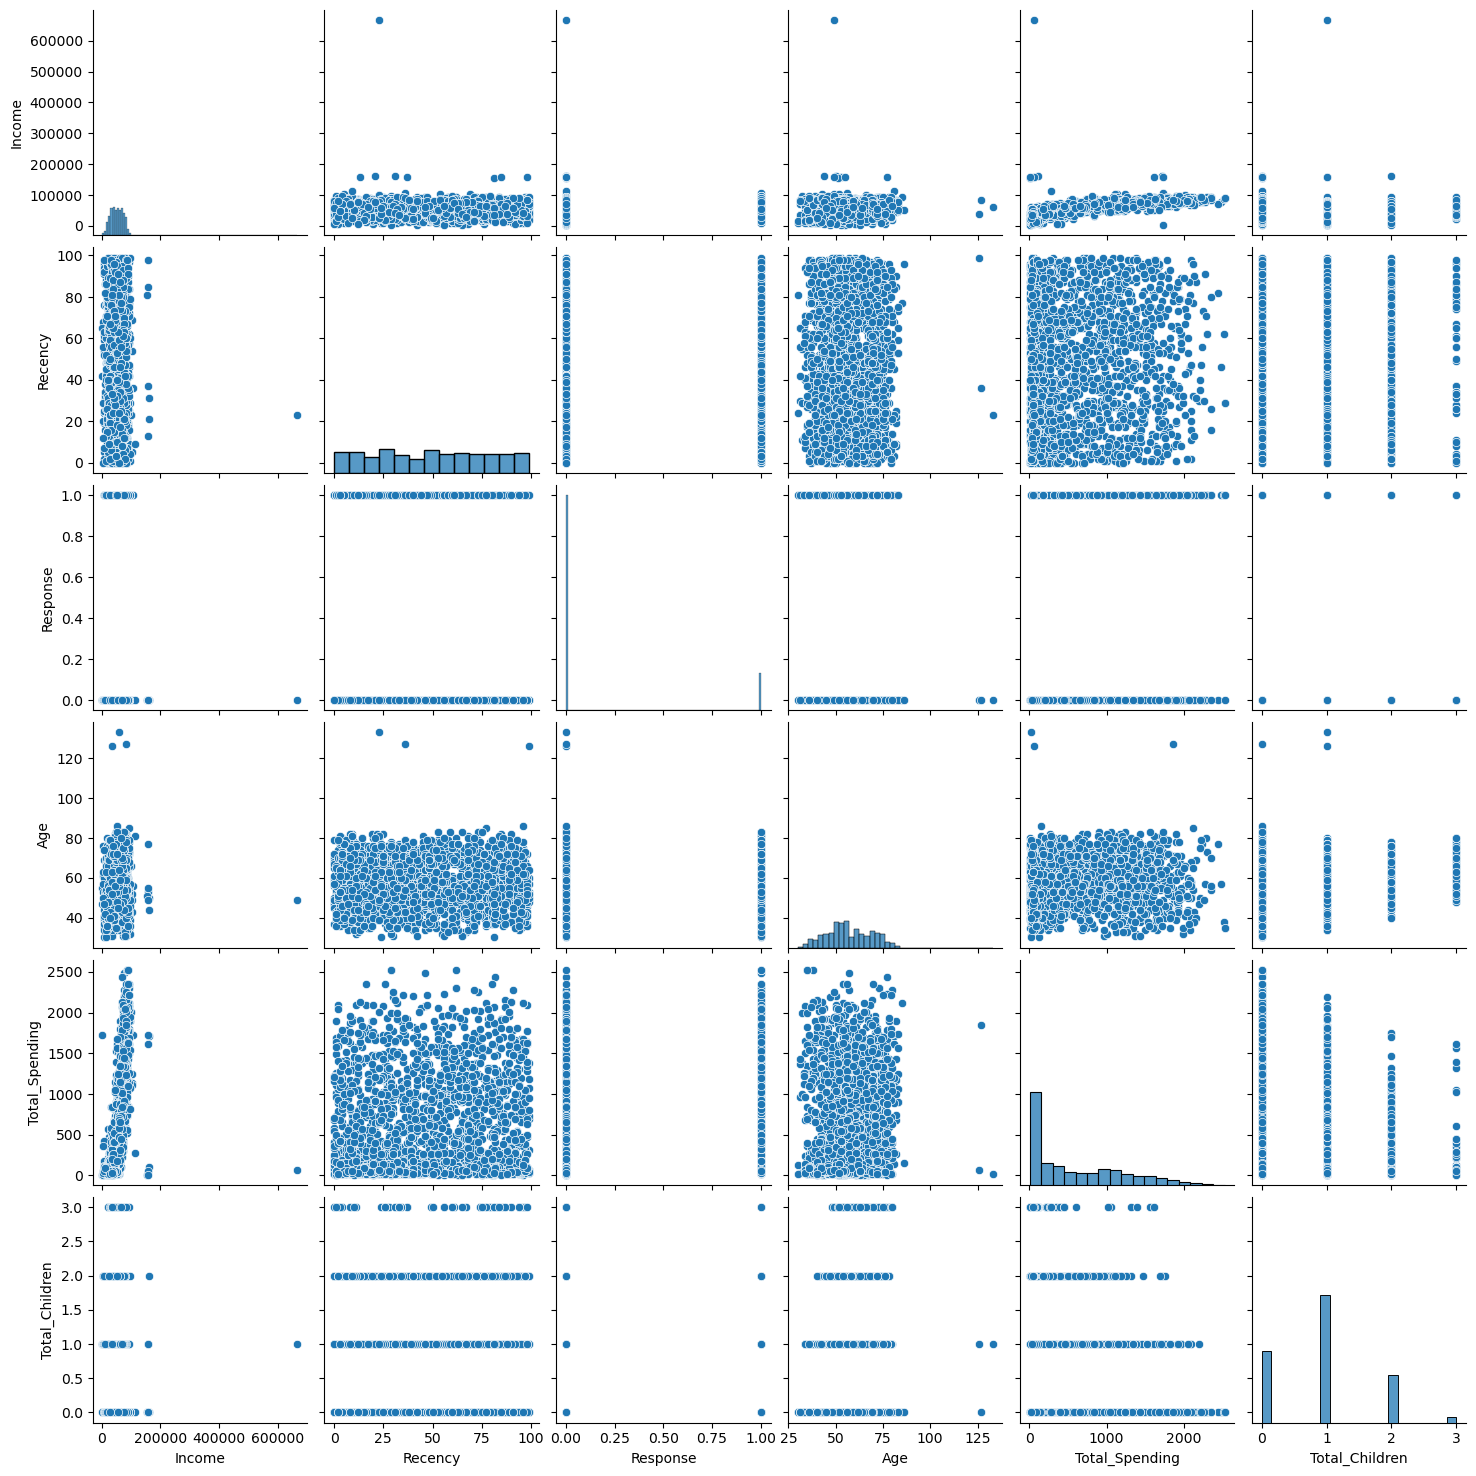

In [87]:
cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending', 'Total_Children']
# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [90]:
# outlier detects at-
#1. income > 60000
#2. age > 90
print("data size with outliers: ", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]< 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]< 600_000)]
print("data size without outliers: ", len(df_cleaned))


data size with outliers:  2236
data size without outliers:  2236


### 4. Heatmap

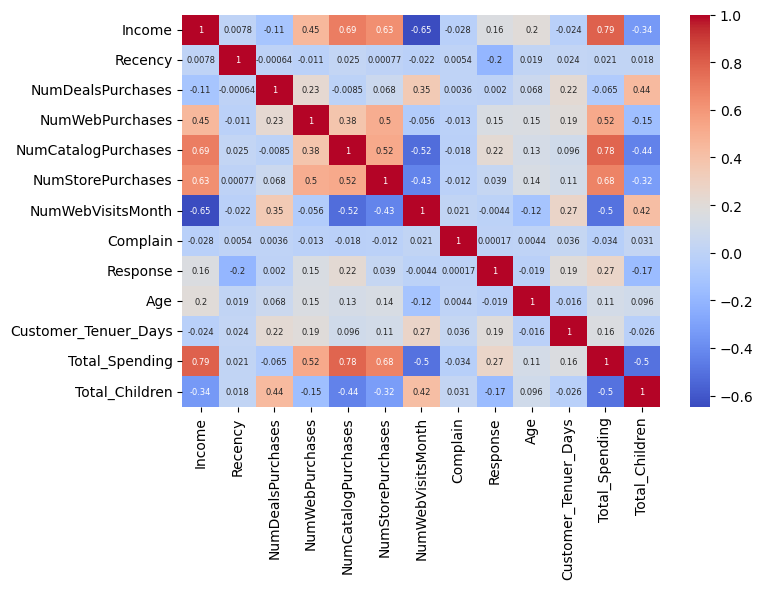

In [91]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)
plt.tight_layout()

### 5. Encoding

In [92]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ['Education', 'Living_With']
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns= ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [93]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

### 6. Scaling

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

### 7. Visualize

In [95]:
X_scaled.shape

(2236, 18)

In [96]:
# need to reduce dimension 18 to 2 or 3

from sklearn.decomposition import PCA

pca  = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

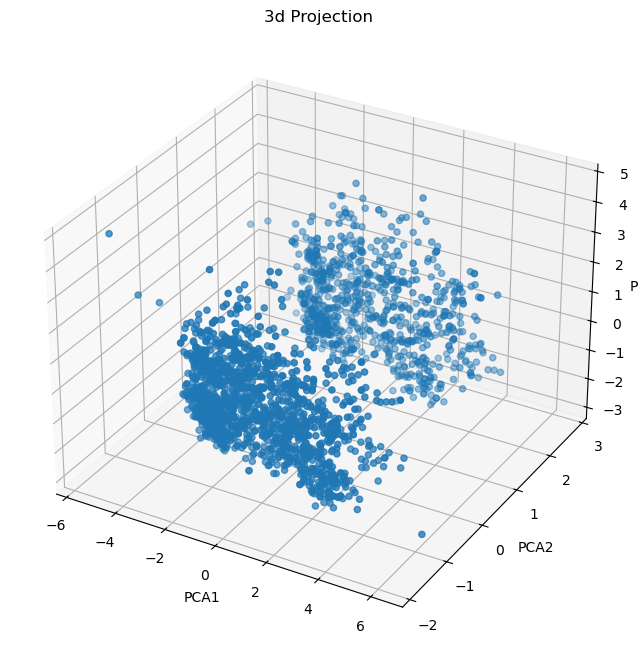

In [97]:
fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:, 1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

In [98]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K Value
### 1. Elbow method

In [99]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [100]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [101]:
optimal_k

np.int64(4)

Text(0.5, 1.0, 'Knee Locator Plot')

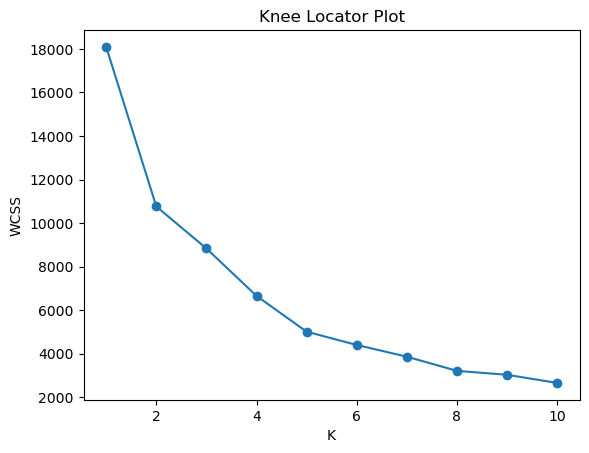

In [102]:
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Knee Locator Plot")

### 2. Silhouette Method

Text(0.5, 1.0, 'Knee Locator Plot')

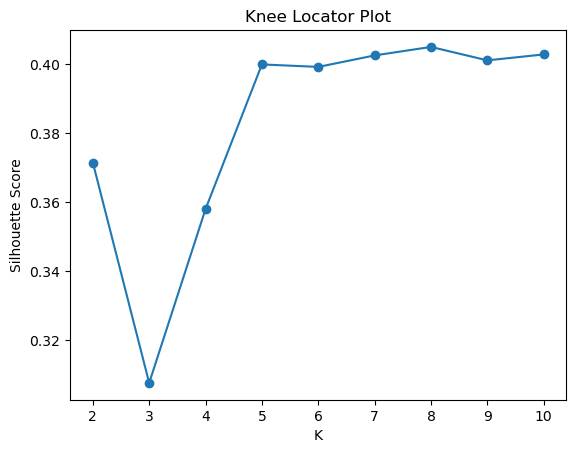

In [103]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Knee Locator Plot")

Text(0, 0.5, 'Silhouette Score')

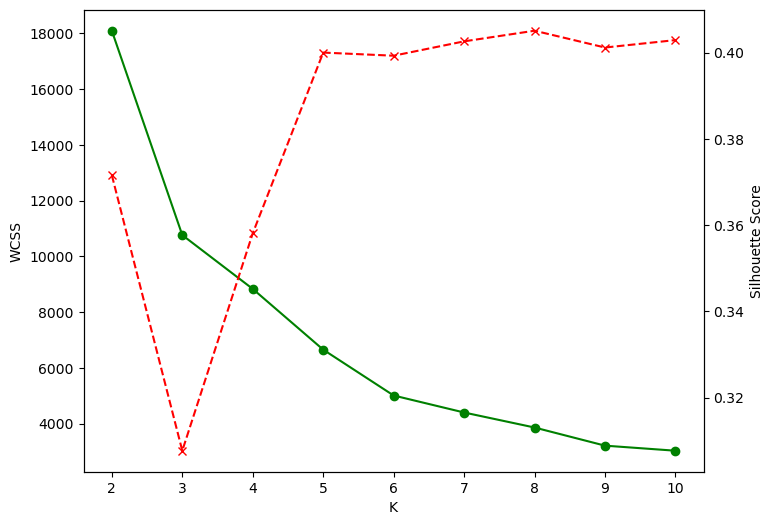

In [104]:
#combined plot
k_range = range(2, 11)
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="green")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()#share same X axis
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

# Clustering

### 1. KMeans Clustering

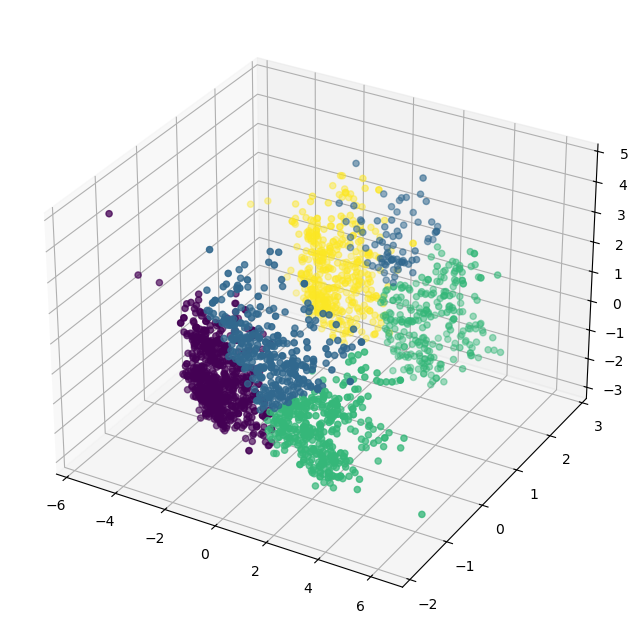

In [105]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:, 1],X_pca[:,2], c=kmeans_labels)

### 2. Agglomerative Clustering

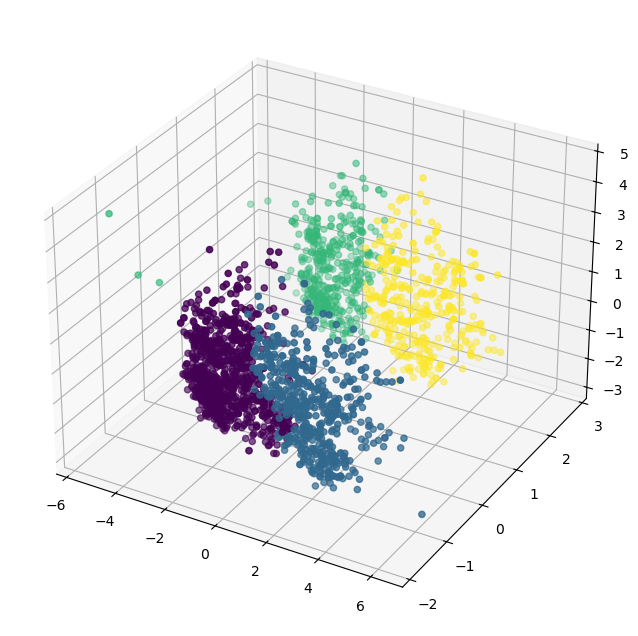

In [106]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")

labels_agg = agg.fit_predict(X_pca)

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:, 1],X_pca[:,2], c=labels_agg)

# Characterization of Clusters

In [115]:
X = df_encoded
X['Clusters'] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenuer_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

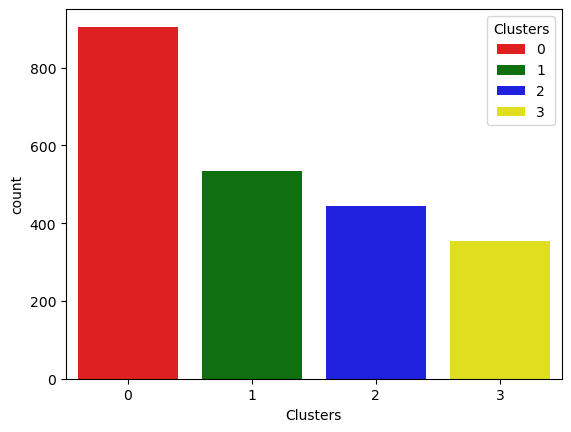

In [116]:
pal = ["red", "green", "blue", "yellow"]

sns.countplot(x=X["Clusters"], palette = pal, hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

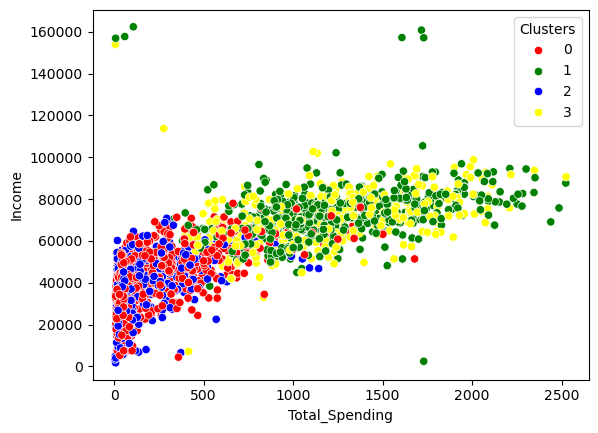

In [117]:
# Income vs Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Clusters"], palette=pal)

# Cluster Summery

In [118]:
cluster_summery = X.groupby("Clusters").mean()
cluster_summery

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenuer_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
Clusters,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000
